# NEAT vs HA-NEAT Ablation – Analysis

**Experiment:** `multi_task_neat_vs_haneat_ablation`  
**Config:** pop=1024, gen=500, disjoint=1.0, 3 seeds per algorithm  
**Algorithms:** NEAT vs HA-NEAT ablation (tanh-only activations)  
**Tasks:** Hopper (11 obs / 3 act) + Walker2D (17 obs / 6 act)  
**Fitness:** normalized_min = min(norm_hopper, norm_walker2d)

**Purpose:** Tests whether activation diversity is the active ingredient in HA-NEAT,
by comparing standard NEAT against HA-NEAT restricted to tanh activations only.

**Sections:**
1. Setup
2. Re-evaluation results
3. Plots
4. Statistical tests

## 1. Setup

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# ── project root on path ────────────────────────────────────────────────────
PROJECT_ROOT = Path(os.getcwd()).parent
for p in [
    str(PROJECT_ROOT),
    str(PROJECT_ROOT / "text" / "figures"),
]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ── analysis modules ────────────────────────────────────────────────────────
from analysis.stats import (
    compute_tests, compute_normalized_min, format_txt_report,
    REFERENCE_REWARDS, TASKS as STAT_TASKS, _seed_means,
)
from plot_evaluation_results import (
    plot_evaluation, ALGO_COLORS, ALGO_DOT_COLORS,
)

# ── constants ────────────────────────────────────────────────────────────────
EXPERIMENT = "multi_task_neat_vs_haneat_ablation"
TASKS      = ["hopper", "walker2d"]

REEVAL_JSON = (
    PROJECT_ROOT / "analysis" / "outputs"
    / "multi_task_neat_vs_haneat_ablation_20260430_165802"
    / "reeval" / "combined.json"
)

FIGURES_DIR = PROJECT_ROOT / "analysis" / "outputs" / "ablation" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root  : {PROJECT_ROOT}")
print(f"Re-eval JSON  : {REEVAL_JSON}  (exists={REEVAL_JSON.exists()})")
print(f"Figures dir   : {FIGURES_DIR}")

Project root  : /Users/svengoerdes/Projects/Thesisv2/tensorneat
Re-eval JSON  : /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/multi_task_neat_vs_haneat_ablation_20260430_165802/reeval/combined.json  (exists=True)
Figures dir   : /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/ablation/figures


## 2. Re-evaluation results

In [2]:
if not REEVAL_JSON.exists():
    raise FileNotFoundError(
        f"Re-evaluation JSON not found: {REEVAL_JSON}\n"
        "Run eval/evaluate_genomes.py on the server first."
    )

print(f"Loading re-evaluation from:\n  {REEVAL_JSON}")
with open(REEVAL_JSON) as f:
    combined = json.load(f)

meta          = combined["metadata"]
runs_ok       = [r for r in combined["runs"] if "error" not in r]
neat_runs     = [r for r in runs_ok if r.get("algorithm") == "neat"]
ablation_runs = [r for r in runs_ok if r.get("algorithm") == "ha_neat_ablation"]

print(f"\nMetadata:")
print(f"  experiment : {meta.get('experiment')}")
print(f"  n_eval     : {meta.get('n_eval')} episodes per genome per task")
print(f"  backend    : {meta.get('backend')}")
print(f"  n_genomes  : {meta.get('n_genomes')}")
print(f"  timestamp  : {meta.get('timestamp')}")
print(f"\nSuccessful re-evaluations: NEAT={len(neat_runs)}, HA-NEAT-ablation={len(ablation_runs)}")

# Summary table
summary = combined.get("summary", {})
rows = []
for algo, label in [("neat", "NEAT"), ("ha_neat_ablation", "HA-NEAT ablation")]:
    if algo not in summary:
        continue
    s = summary[algo]
    for task in TASKS:
        if task not in s:
            continue
        t = s[task]
        rows.append({
            "Algorithm"  : label,
            "Task"       : task.capitalize(),
            "Mean reward": f"{t['mean_across_seeds']:.1f} ± {t['std_across_seeds']:.1f}",
            "Mean norm." : f"{t['mean_normalized']:.4f} ± {t['std_normalized']:.4f}",
            "N seeds"    : t["n_seeds"],
        })

df_summary = pd.DataFrame(rows).set_index(["Algorithm", "Task"])
print()
display(df_summary)

Loading re-evaluation from:
  /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/multi_task_neat_vs_haneat_ablation_20260430_165802/reeval/combined.json

Metadata:
  experiment : combined_final
  n_eval     : 30 episodes per genome per task
  backend    : mjx
  n_genomes  : 6
  timestamp  : 20260430_174153

Successful re-evaluations: NEAT=3, HA-NEAT-ablation=3



Mean reward       Mean norm.  N seeds
Algorithm Task                                              
NEAT      Hopper     1059.0 ± 42.5  0.3530 ± 0.0142        3
          Walker2d  1287.5 ± 518.5  0.2575 ± 0.1037        3

## 3. Plots

In [3]:
# 3a. Grouped bar charts (normalised)
# Remap ha_neat_ablation → ha_neat so the existing plot_evaluation function works
combined_remapped = dict(combined)
combined_remapped["runs"] = [
    dict(r, algorithm="ha_neat") if r.get("algorithm") == "ha_neat_ablation" else r
    for r in combined["runs"]
]
# Update summary key as well
summary_remapped = {}
if "neat" in combined["summary"]:
    summary_remapped["neat"] = combined["summary"]["neat"]
if "ha_neat_ablation" in combined["summary"]:
    summary_remapped["ha_neat"] = combined["summary"]["ha_neat_ablation"]
combined_remapped["summary"] = summary_remapped
combined_remapped["metadata"] = dict(combined["metadata"], experiment=EXPERIMENT)

plot_evaluation(combined_remapped, TASKS, str(FIGURES_DIR), "pdf", normalized=True)
plot_evaluation(combined_remapped, TASKS, str(FIGURES_DIR), "pdf", normalized=False)

  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/ablation/figures/multi_task_neat_vs_haneat_ablation_evaluation_normalized.pdf
  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/ablation/figures/multi_task_neat_vs_haneat_ablation_evaluation.pdf


  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/ablation/figures/distribution_violin.pdf


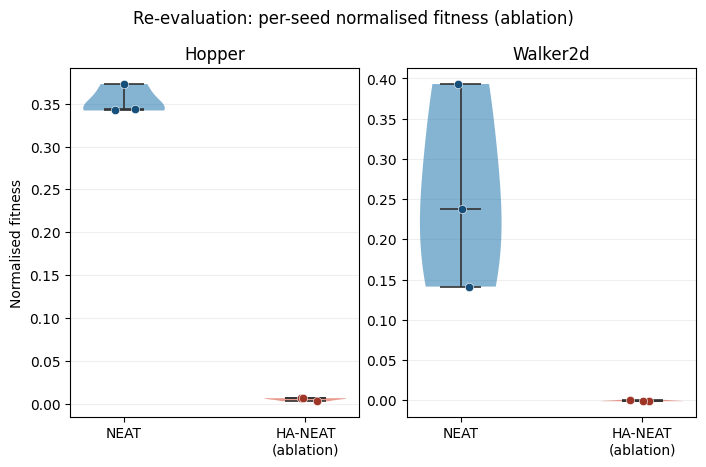

In [4]:
# 3b. Distribution violin + strip plots
def _seed_task_means_norm(run_list, task):
    ref = REFERENCE_REWARDS.get(task, 1.0)
    return np.array([r["tasks"][task]["mean"] / ref
                     for r in run_list if task in r.get("tasks", {})])

fig, axes = plt.subplots(1, len(TASKS), figsize=(7, 4.5))
rng = np.random.default_rng(1)

for ax, task in zip(axes, TASKS):
    neat_vals  = _seed_task_means_norm(neat_runs, task)
    abl_vals   = _seed_task_means_norm(ablation_runs, task)

    positions = [0, 1]
    vp = ax.violinplot([neat_vals, abl_vals], positions=positions,
                       showmedians=True, widths=0.45)
    colors = [ALGO_COLORS["neat"], ALGO_COLORS["ha_neat"]]
    for body, c in zip(vp["bodies"], colors):
        body.set_facecolor(c)
        body.set_alpha(0.55)
    for part in ["cbars", "cmins", "cmaxes", "cmedians"]:
        vp[part].set_color("#333333")
        vp[part].set_linewidth(1.2)

    for pos, vals, dc in zip(positions,
                              [neat_vals, abl_vals],
                              [ALGO_DOT_COLORS["neat"], ALGO_DOT_COLORS["ha_neat"]]):
        jitter = rng.uniform(-0.07, 0.07, len(vals))
        ax.scatter(np.full(len(vals), pos) + jitter, vals,
                   color=dc, s=36, zorder=5, edgecolors="white", linewidths=0.4)

    ax.set_xticks(positions)
    ax.set_xticklabels(["NEAT", "HA-NEAT\n(ablation)"])
    ax.set_ylabel("Normalised fitness" if task == TASKS[0] else "")
    ax.set_title(task.capitalize())
    ax.yaxis.grid(True, alpha=0.3, color="#cccccc")
    ax.set_axisbelow(True)

fig.suptitle("Re-evaluation: per-seed normalised fitness (ablation)", y=1.01)
fig.tight_layout(pad=0.5)
fig.savefig(FIGURES_DIR / "distribution_violin.pdf")
print(f"  Saved: {FIGURES_DIR / 'distribution_violin.pdf'}")
plt.show()
plt.close(fig)

## 4. Statistical tests

In [5]:
test_results = compute_tests(neat_runs, ablation_runs, label_a="neat", label_b="ha_neat_ablation")
print(format_txt_report(test_results, label_a="NEAT", label_b="HA-NEAT ablation"))

Statistical Comparison: NEAT vs HA-NEAT ablation

  Task: HOPPER

  n: NEAT=3, HA-NEAT ablation=3
  Mean: NEAT=1059.0 ± 52.1  HA-NEAT ablation=14.9 ± 5.9
  Norm mean (/3000): NEAT=0.3530  HA-NEAT ablation=0.0050

  1. Mann-Whitney U: U=9.0, p=0.1000

  2. Exact permutation test:
     observed diff=1044.1, p=0.1008 (10000 permutations)

  3. Cohen's d: 28.161 (large)

  Task: WALKER2D

  n: NEAT=3, HA-NEAT ablation=3
  Mean: NEAT=1287.5 ± 635.1  HA-NEAT ablation=-3.2 ± 4.7
  Norm mean (/5000): NEAT=0.2575  HA-NEAT ablation=-0.0006

  1. Mann-Whitney U: U=9.0, p=0.1000

  2. Exact permutation test:
     observed diff=1290.7, p=0.1008 (10000 permutations)

  3. Cohen's d: 2.874 (large)

  Task: NORMALIZED_MIN

  n: NEAT=3, HA-NEAT ablation=3
  Mean: NEAT=0.2 ± 0.1  HA-NEAT ablation=-0.0 ± 0.0
  Norm mean (/1.0): NEAT=0.2411  HA-NEAT ablation=-0.0006

  1. Mann-Whitney U: U=9.0, p=0.1000

  2. Exact permutation test:
     observed diff=0.2, p=0.1008 (10000 permutations)

  3. Cohen's d: 3.

In [6]:
# Bootstrap 95% CIs (10 000 resamples)
def bootstrap_ci(values, stat=np.mean, n=10_000, seed=42, alpha=0.05):
    rng = np.random.default_rng(seed)
    arr = np.asarray(values)
    boots = [stat(rng.choice(arr, size=len(arr), replace=True)) for _ in range(n)]
    lo = np.percentile(boots, 100 * alpha / 2)
    hi = np.percentile(boots, 100 * (1 - alpha / 2))
    return float(lo), float(hi)

def format_ci(val, lo, hi, ref=1.0):
    return f"{val/ref:.4f} [{lo/ref:.4f}, {hi/ref:.4f}]"

table_rows = []
for task in TASKS + ["normalized_min"]:
    ref = REFERENCE_REWARDS.get(task, 1.0)
    r   = test_results[task]

    if task == "normalized_min":
        ma  = np.array(compute_normalized_min(neat_runs))
        mb  = np.array(compute_normalized_min(ablation_runs))
        ref = 1.0
    else:
        ma = _seed_means(neat_runs, task)
        mb = _seed_means(ablation_runs, task)

    ci_a  = bootstrap_ci(ma)
    ci_b  = bootstrap_ci(mb)
    # diff CIs need equal-length arrays
    min_len = min(len(ma), len(mb))
    diffs   = bootstrap_ci(mb[:min_len] - ma[:min_len])
    obs_diff = r["observed_diff"]

    table_rows.append({
        "Task"                    : task,
        "NEAT mean [95%CI]"       : format_ci(r["mean_a"], *ci_a, ref=ref),
        "HA-NEAT abl. mean [95%CI]": format_ci(r["mean_b"], *ci_b, ref=ref),
        "Δ mean [95%CI]"          : f"{obs_diff/ref:.4f} [{diffs[0]/ref:.4f}, {diffs[1]/ref:.4f}]",
        "Mann-Whitney p"          : f"{r['p_mannwhitney']:.4f}" if r['p_mannwhitney'] is not None else "n/a",
        "Permutation p"           : f"{r['p_permutation']:.4f}",
        "Cohen's d"               : f"{r['cohens_d']:.3f} ({r['magnitude']})",
    })

df_stats = pd.DataFrame(table_rows).set_index("Task")
display(df_stats)

,NEAT mean [95%CI],HA-NEAT abl. mean [95%CI],Δ mean [95%CI],Mann-Whitney p,Permutation p,Cohen's d
Task,,,,,,
hopper,"0.3530 [0.3421, 0.3730]","0.0050 [0.0027, 0.0062]","0.3480 [-0.3703, -0.3359]",0.1000,0.1008,28.161 (large)
walker2d,"0.2575 [0.1413, 0.3931]","-0.0006 [-0.0012, 0.0004]","0.2581 [-0.3943, -0.1408]",0.1000,0.1008,2.874 (large)
normalized_min,"0.2411 [0.1413, 0.3438]","-0.0006 [-0.0012, 0.0004]","0.2417 [-0.3450, -0.1408]",0.1000,0.1008,3.375 (large)
